**Step 1 : Installation and Requirements**

In [2]:
!pip install -U transformers accelerate datasets scikit-learn seaborn matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 138.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 136.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 53.4 MB/s eta 0:00:00


In [3]:
import torch
print("PyTorch version:", torch.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

PyTorch version: 2.9.0+cu126
GPU: NVIDIA A100-SXM4-80GB


In [4]:
from google.colab import drive
import os

# Dataset
import pandas as pd
from datasets import Dataset

# ERS
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.multiclass import OneVsRestClassifier

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# LLM
from transformers import AutoTokenizer, AutoModelForCausalLM

# regular expression
import re

# save and load model
import joblib

**Step 2 : Mount Libraries & Dataset**

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
project_dir = "/content/drive/MyDrive/TA/IPYNB"
os.makedirs(project_dir, exist_ok=True)
os.chdir(project_dir)

# Dataset Folder
dataset_dir = "/content/drive/MyDrive/TA/IPYNB/Datasets"

print("Project directory:", os.getcwd())
print("Dataset directory:", dataset_dir)
print("Dataset files:", os.listdir(dataset_dir))

Project directory: /content/drive/MyDrive/TA/IPYNB
Dataset directory: /content/drive/MyDrive/TA/IPYNB/Datasets
Dataset files: ['dialogues_act.txt', 'dialogues_emotion.txt', 'dialogues_topic.txt', 'dialogues_text.txt', 'test.txt', 'val.txt', 'chatbot dataset.txt', 'train.csv', 'test.csv', 'validation.csv', 'Emotion_classify_Data.csv', 'train.txt', 'RevisedDataset', 'synthetic_emotion_data.txt', 'Sources']


**Step 3 : Load Dataset & Pre-Processing**

In [7]:
# DailyDialog Dataset
train_df = pd.read_csv(f"{dataset_dir}/train.txt", sep=';', header=None, names=["text","label"])
val_df   = pd.read_csv(f"{dataset_dir}/val.txt",   sep=';', header=None, names=["text","label"])
test_df  = pd.read_csv(f"{dataset_dir}/test.txt",  sep=';', header=None, names=["text","label"])

print("Train head:")
display(train_df.head())

Train head:


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [8]:
# Label encoding
labels = sorted(train_df["label"].unique())
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {v: k for k, v in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)
val_df["label_id"]   = val_df["label"].map(label2id)
test_df["label_id"]  = test_df["label"].map(label2id)

In [9]:
print("Label Encoding (label → label_id):")
for l, i in label2id.items():
  print(f"{l:10s} → {i}")

Label Encoding (label → label_id):
anger      → 0
fear       → 1
joy        → 2
love       → 3
sadness    → 4
surprise   → 5


In [10]:
train_df.head(10)

,text,label,label_id
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0
5,ive been feeling a little burdened lately wasn...,sadness,4
6,ive been taking or milligrams or times recomme...,surprise,5
7,i feel as confused about life as a teenager or...,fear,1
8,i have been with petronas for years i feel tha...,joy,2
9,i feel romantic too,love,3


In [11]:
print("label2id =", label2id)
print("id2label =", id2label)

label2id = {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
id2label = {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}


In [12]:
train_base = Dataset.from_pandas(train_df)
val_base   = Dataset.from_pandas(val_df)
test_base  = Dataset.from_pandas(test_df)

**Step 4 : Emotion Recognition System (ERS)**

In [13]:
class CustomMachineLearningERS:
  def __init__(self):
    print("Initializing Custom Machine Learning ERS...")
    self.pipeline = Pipeline([
      ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2)
      )),
      ("clf", OneVsRestClassifier(
          LogisticRegression(
          C=1.0,
          solver="liblinear",
          class_weight="balanced",
          max_iter=2000 # <-- Higher Maximum Iteration
        )
      ))
    ])
    self.is_trained = False

  def train(self, texts, labels):
    print("Training the ERS model...")
    self.pipeline.fit(list(texts), list(labels))
    self.is_trained = True
    print("✅ ERS Training complete.")

  def evaluate(self, texts, labels):
    if not self.is_trained:
      print("⚠️ Model is not trained yet.")
      return None

    if texts is None or labels is None or len(texts) == 0 or len(labels) == 0:
      print("⚠️ Evaluation skipped: Test data is empty.")
      return None

    predictions = self.pipeline.predict(list(texts))
    print("\n--- ERS Evaluation Report on Test Data ---")
    print(classification_report(list(labels), predictions, zero_division=0))
    print("------------------------------------------")
    return predictions

  def predict_emotion(self, text):
    if not self.is_trained:
      return "neutral"
    return self.pipeline.predict([text])[0]

**Step 5 : ERS Training**

In [14]:
print("\n===== TRAINING FINAL ERS MODEL (train + val) =====")

final_X = train_df["text"].tolist() + val_df["text"].tolist()
final_y = train_df["label"].tolist() + val_df["label"].tolist()

ers = CustomMachineLearningERS()
ers.train(final_X, final_y)

print("\n===== FINAL ERS EVALUATION (test) =====")
preds_ers = ers.evaluate(test_df["text"].tolist(), test_df["label"].tolist())


===== TRAINING FINAL ERS MODEL (train + val) =====
Initializing Custom Machine Learning ERS...
Training the ERS model...
✅ ERS Training complete.

===== FINAL ERS EVALUATION (test) =====

--- ERS Evaluation Report on Test Data ---
              precision    recall  f1-score   support

       anger       0.87      0.89      0.88       275
        fear       0.89      0.81      0.85       224
         joy       0.92      0.90      0.91       695
        love       0.72      0.87      0.79       159
     sadness       0.93      0.90      0.91       581
    surprise       0.62      0.80      0.70        66

    accuracy                           0.88      2000
   macro avg       0.82      0.86      0.84      2000
weighted avg       0.89      0.88      0.88      2000

------------------------------------------


**Confusion Matrix**

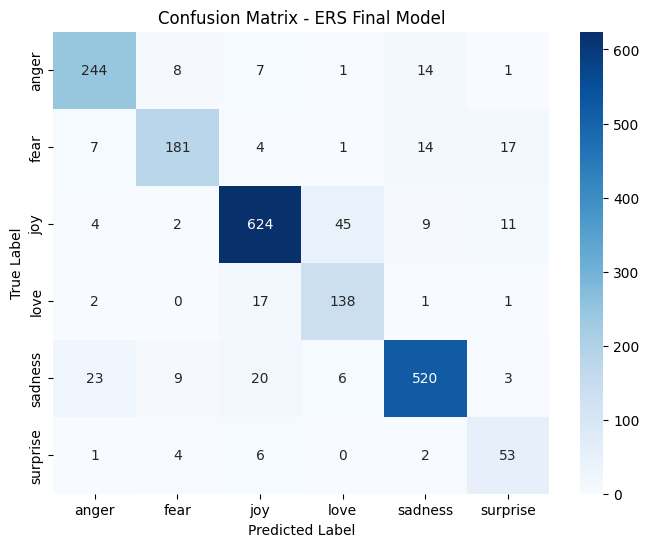

In [15]:
def plot_confusion_matrix(true_labels, pred_labels, classes):
  cm = confusion_matrix(true_labels, pred_labels, labels=classes)
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix - ERS Final Model")
  plt.show()

plot_confusion_matrix(test_df["label"], preds_ers, classes=labels)

**Step 6 : Load Qwen Model**

In [16]:
LLM_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer_llm = AutoTokenizer.from_pretrained(
  LLM_NAME,
  trust_remote_code=True
)

model_llm = AutoModelForCausalLM.from_pretrained(
  LLM_NAME,
  device_map="auto",
  torch_dtype=torch.bfloat16,
  trust_remote_code=True
)

if tokenizer_llm.pad_token is None:
  tokenizer_llm.pad_token = tokenizer_llm.eos_token
model_llm.config.pad_token_id = tokenizer_llm.pad_token_id


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

**Step 7 : ERS -> Qwen Integration**

In [17]:
def generate_response(user_text, ers_model, tokenizer, model):
    emotion = ers_model.predict_emotion(user_text)

    prompt = (
        f"The user is feeling {emotion}.\n"
        f'User: "{user_text}"\n\n'
        "As a supportive and empathetic assistant, reply with:\n"
        "- A short emotional validation\n"
        "- A warm, natural tone\n"
        "- No analysis, no lists, no explanations\n"
        "- No repeating the prompt\n"
        "- No mentioning the emotion directly\n"
        "- Do NOT write 'User:' or 'Assistant:'\n"
        "Give only one or two natural sentences.\n\n"
        "Assistant:"
    )

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=80,
            temperature=0.8,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.15,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    full_output = tokenizer.decode(output[0], skip_special_tokens=True)

    # Take respond ater Assistant
    if "Assistant:" in full_output:
        response = full_output.rsplit("Assistant:", 1)[-1].strip()
    else:
        response = full_output.strip()

    # Clean up if model writes role tags
    response = re.sub(r'^(Assistant:|User:)\s*', '', response, flags=re.IGNORECASE).strip()

    # Force 2 Max Sentences
    sents = re.split(r'(?<=[.!?])\s+', response)
    response = " ".join(sents[:2]).strip()

    return emotion, response


**Step 8 : Sanity Check**

In [18]:
test_inputs = [
  "I feel exhausted and worthless.",
  "I finally graduated today, I'm so happy!",
  "I'm really angry about what happened at work.",
  "I'm scared of failing and not knowing what to do.",
  "Today I feel peaceful and calm.",
]

print("\n===== SANITY CHECK RESULTS =====\n")

for text in test_inputs:
  emo, resp = generate_response(text, ers, tokenizer_llm, model_llm)

  print(f"USER INPUT      : {text}")
  print(f"DETECTED EMOTION: {emo}")
  print(f"MODEL RESPONSE  : {resp}")
  print("-" * 80)



===== SANITY CHECK RESULTS =====

USER INPUT      : I feel exhausted and worthless.
DETECTED EMOTION: sadness
MODEL RESPONSE  : It's okay to feel that way sometimes. Take it one day at a time; we're all in this together.
--------------------------------------------------------------------------------
USER INPUT      : I finally graduated today, I'm so happy!
DETECTED EMOTION: joy
MODEL RESPONSE  : Congrats on your graduation! That must feel amazing.
--------------------------------------------------------------------------------
USER INPUT      : I'm really angry about what happened at work.
DETECTED EMOTION: anger
MODEL RESPONSE  : It sounds like you've had quite an upsetting day. I can see how that would make you feel angry.
--------------------------------------------------------------------------------
USER INPUT      : I'm scared of failing and not knowing what to do.
DETECTED EMOTION: fear
MODEL RESPONSE  : It's totally okay to feel this way. Everyone has moments when they're af

**Step 9 : Save Model**

In [19]:
save_dir = "/content/drive/MyDrive/TA/Models"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(ers, f"{save_dir}/ers_model.pkl")

print("ERS model saved successfully at:", f"{save_dir}/ers_model.pkl")


ERS model saved successfully at: /content/drive/MyDrive/TA/Models/ers_model.pkl


**DEMO**

In [20]:
def simple_chat():
  print("=== SIMPLE EMOTION-AWARE CHATBOT DEMO ===")
  print("Type 'exit' to stop.\n")

  while True:
    user_input = input("User : ")

    if user_input.lower() == "exit":
      print("Demo ended.")
      break

      # Pipeline: ERS → Qwen
    emo, bot_response = generate_response(
      user_input,
      ers,
      tokenizer_llm,
      model_llm
    )

    print(f"Detected Emotion : {emo}")
    print(f"Bot Response     : {bot_response}\n")


In [21]:
simple_chat()

=== SIMPLE EMOTION-AWARE CHATBOT DEMO ===
Type 'exit' to stop.

User : exit
Demo ended.


**DEBUG**

In [23]:
# ===== Extract params from the trained ERS pipeline =====
pipeline = ers.pipeline

# TF-IDF params
tfidf = pipeline.named_steps["tfidf"]
print("TF-IDF params (selected):")
keys_tfidf = ["max_features", "ngram_range", "min_df", "max_df", "use_idf", "smooth_idf",
              "sublinear_tf", "norm", "stop_words", "analyzer"]
print({k: tfidf.get_params().get(k) for k in keys_tfidf})

# LR params (note: your clf is OneVsRestClassifier(LogisticRegression))
clf = pipeline.named_steps["clf"]                 # OneVsRestClassifier(...)
lr = clf.estimator                                # LogisticRegression(...)
print("\nLogistic Regression params (selected):")
keys_lr = ["C", "solver", "class_weight", "max_iter", "penalty", "multi_class", "n_jobs", "random_state"]
print({k: lr.get_params().get(k) for k in keys_lr})

print("\nPipeline keys:")
print(pipeline.named_steps)


TF-IDF params (selected):
{'max_features': 10000, 'ngram_range': (1, 2), 'min_df': 1, 'max_df': 1.0, 'use_idf': True, 'smooth_idf': True, 'sublinear_tf': False, 'norm': 'l2', 'stop_words': None, 'analyzer': 'word'}

Logistic Regression params (selected):
{'C': 1.0, 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'deprecated', 'multi_class': None, 'n_jobs': None, 'random_state': None}

Pipeline keys:
{'tfidf': TfidfVectorizer(max_features=10000, ngram_range=(1, 2)), 'clf': OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=2000,
                                                 solver='liblinear'))}


In [27]:
ers.train(final_X, final_y)

Training the ERS model...
✅ ERS Training complete.


In [28]:
pipeline = ers.pipeline
print("Named steps:", pipeline.named_steps)

ovr = pipeline.named_steps["clf"]
print("Classifier type:", type(ovr))
print("Has coef_?", hasattr(ovr, "coef_"))
print("Has classes_?", hasattr(ovr, "classes_"))
print("Has estimators_?", hasattr(ovr, "estimators_"))


Named steps: {'tfidf': TfidfVectorizer(max_features=10000, ngram_range=(1, 2)), 'clf': OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=2000,
                                                 solver='liblinear'))}
Classifier type: <class 'sklearn.multiclass.OneVsRestClassifier'>
Has coef_? False
Has classes_? True
Has estimators_? True


In [29]:
import numpy as np
import pandas as pd

pipeline = ers.pipeline
tfidf = pipeline.named_steps["tfidf"]
ovr = pipeline.named_steps["clf"]

feature_names = tfidf.get_feature_names_out()
classes = ovr.classes_

# Ambil coef dari masing-masing estimator LR (1 per class)
coef = np.vstack([est.coef_.ravel() for est in ovr.estimators_])  # (n_classes, n_features)

top_k = 10
rows = []
for i, cls in enumerate(classes):
    top_idx = np.argsort(coef[i])[::-1][:top_k]
    rows.append({
        "emotion": str(cls),
        "top_terms": ", ".join(feature_names[top_idx]),
        "top_weights": ", ".join([f"{w:.4f}" for w in coef[i][top_idx]]),
    })

df_top = pd.DataFrame(rows).sort_values("emotion")
df_top


,emotion,top_terms,top_weights
0,anger,"dangerous, greedy, violent, irritable, dissati...","8.5913, 8.1505, 8.0186, 8.0164, 7.6956, 7.6569..."
1,fear,"shaken, terrified, vulnerable, scared, paranoi...","9.2652, 9.1799, 8.7469, 8.3393, 8.2395, 7.8369..."
2,joy,"innocent, sincere, cute, pleasant, superior, s...","4.9330, 4.7611, 4.7104, 4.7047, 4.6884, 4.6305..."
3,love,"sympathetic, loving, caring, nostalgic, hot, n...","9.9906, 9.9699, 9.9684, 9.8954, 9.7885, 9.7348..."
4,sadness,"melancholy, troubled, shitty, punished, lethar...","5.6041, 5.4324, 5.2887, 5.2580, 5.2377, 5.2124..."
5,surprise,"amazed, impressed, curious, funny, surprised, ...","14.1853, 14.1722, 13.6906, 13.5789, 13.5633, 1..."


In [30]:
top_k = 5
rows = []
for i, cls in enumerate(classes):
    top_idx = np.argsort(coef[i])[::-1][:top_k]
    rows.append({
        "Emotion": str(cls),
        "Top terms": ", ".join(feature_names[top_idx]),
    })
df_report = pd.DataFrame(rows).sort_values("Emotion")
df_report


,Emotion,Top terms
0,anger,"dangerous, greedy, violent, irritable, dissati..."
1,fear,"shaken, terrified, vulnerable, scared, paranoid"
2,joy,"innocent, sincere, cute, pleasant, superior"
3,love,"sympathetic, loving, caring, nostalgic, hot"
4,sadness,"melancholy, troubled, shitty, punished, lethargic"
5,surprise,"amazed, impressed, curious, funny, surprised"


In [31]:
import numpy as np
import pandas as pd

pipeline = ers.pipeline
tfidf = pipeline.named_steps["tfidf"]
ovr = pipeline.named_steps["clf"]

feature_names = tfidf.get_feature_names_out()
classes = ovr.classes_
coef = np.vstack([est.coef_.ravel() for est in ovr.estimators_])

top_k = 5
rows = []
for i, cls in enumerate(classes):
    top_idx = np.argsort(coef[i])[::-1][:top_k]
    pairs = [f"{feature_names[j]} ({coef[i][j]:.4f})" for j in top_idx]
    rows.append({
        "Emotion": str(cls),
        "Top TF-IDF features (LR coefficients)": ", ".join(pairs)
    })

df_report = pd.DataFrame(rows).sort_values("Emotion")
df_report


,Emotion,Top TF-IDF features (LR coefficients)
0,anger,"dangerous (8.5913), greedy (8.1505), violent (..."
1,fear,"shaken (9.2652), terrified (9.1799), vulnerabl..."
2,joy,"innocent (4.9330), sincere (4.7611), cute (4.7..."
3,love,"sympathetic (9.9906), loving (9.9699), caring ..."
4,sadness,"melancholy (5.6041), troubled (5.4324), shitty..."
5,surprise,"amazed (14.1853), impressed (14.1722), curious..."
